# 03 - Feature Engineering
## Airbnb Price Prediction - Austin, TX

**Purpose of this notebook**  
Transform the cleaned dataset into a feature-engineered dataset ready for preprocessing. 
Six derived features are created here, each with an explicit business hypothesis. These 
features capture signal that the raw columns alone cannot express: spatial context 
(distance to city center, geographic clustering, local density), space utilization 
(guests per bedroom, bathrooms per guest), and amenity quality (tiered scoring).

**What this notebook does NOT do**  
- No imputation, encoding, scaling, or train/test split (deferred to `04_Preprocessing.ipynb`)
- No `log1p` transformation of the target (deferred to `04_Preprocessing.ipynb`)
- No new feature outside the 14 defined in the project specification

**Inference-time constraint**  
> Every engineered feature must be computable from the inputs a host can provide in 
> the Streamlit app: address, property type, room type, capacity, amenities, availability. 
> No feature derived from review history, host history, or post-listing metrics.

**Input**: `data/processed/Austin/data_cleaned.parquet` (10,503 rows × 12 columns)  
**Output**: `data/processed/Austin/data_features.parquet` (10,503 rows × 14 columns expected)

**Outline**
1. Setup & Data Loading
2. Geographic feature - distance to downtown
3. Geographic feature - cluster of listings
4. Geographic feature - local listings density
5. Capacity ratio - guests per bedroom
6. Capacity ratio - bathrooms per guest
7. Amenity tier - concept-based weighted scoring
8. Final Audit & Export

---
## 1. Setup & Data Loading

We reload the parquet output of Notebook 02. Parquet preserves dtypes, so 
`neighbourhood_cleansed` arrives already typed as `category` and we do not need 
to reparse anything.

The only libraries needed beyond the standard `pandas` and `numpy` are `sklearn.cluster.KMeans` 
(for `geo_cluster`) and `sklearn.neighbors.BallTree` (for `listings_density_500m`), 
plus `ast` to parse the `amenities` list stored as a string. We also import 
`matplotlib` and `seaborn` to validate each engineered feature visually.

In [1]:
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.neighbors import BallTree

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid')

print('Libraries loaded')

Libraries loaded


In [2]:
INPUT_PATH = '../data/processed/Austin/data_cleaned.parquet'

df = pd.read_parquet(INPUT_PATH)

print(f'Loaded data_cleaned.parquet: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('Dtypes:')
print(df.dtypes)
print()
print('First rows:')
df.head(3)

Loaded data_cleaned.parquet: 10,503 rows × 12 columns

Dtypes:
neighbourhood_cleansed      int64
latitude                  float64
longitude                 float64
property_type                 str
room_type                     str
accommodates                int64
bathrooms_clean           float64
bedrooms                  float64
beds                      float64
amenities                     str
price                     float64
availability_365            int64
dtype: object

First rows:


,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_clean,bedrooms,beds,amenities,price,availability_365
0,78702,30.26,-97.73,Entire guesthouse,Entire home/apt,3,1.00,1.00,2.00,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",97.00,328
1,78704,30.26,-97.76,Entire guesthouse,Entire home/apt,2,1.00,1.00,2.00,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",160.00,316
2,78741,30.23,-97.74,Entire guest suite,Entire home/apt,2,1.00,1.00,1.00,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",38.00,88


---
## 2. Geographic feature - distance to downtown

**Business hypothesis**  
Listings closer to Austin's central business district command higher nightly rates 
due to proximity to entertainment, restaurants, employment hubs, and major venues. 
Notebook 01 confirmed this empirically: median price drops monotonically as we move 
outward from the downtown ZIP codes. Collapsing latitude and longitude into a single 
continuous "centrality" feature gives linear models a usable geographic signal (they 
cannot exploit raw coordinates) and tree-based models a cleaner split variable than 
the two raw coordinates considered separately.

**Reference point**  
We use the Texas State Capitol at (30.2747, -97.7404) as the city-center anchor. 
The Capitol sits at the geographic heart of Austin's downtown grid and is the 
standard reference in local real-estate analyses. Two alternatives were considered 
and rejected: the centroid of downtown listings (data-dependent, unstable across 
snapshots) and the centroid of Austin's administrative boundary (skewed westward by 
the city's irregular shape).

**Method**  
Haversine distance, vectorized over the full column. Haversine is the exact 
great-circle distance and is preferred to a Euclidean approximation on (lat, lon) 
at Austin's latitude (~30 degrees N), where one degree of longitude is noticeably 
shorter than one degree of latitude.

In [3]:
# City center: Texas State Capitol
DOWNTOWN_LAT = 30.2747
DOWNTOWN_LON = -97.7404
EARTH_RADIUS_KM = 6371.0


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between (lat, lon) points in degrees.
    Vectorized: any input can be a scalar or array; NumPy broadcasting applies.
    """
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))


df['distance_to_downtown_km'] = haversine_km(
    df['latitude'].values,
    df['longitude'].values,
    DOWNTOWN_LAT,
    DOWNTOWN_LON,
)

print('distance_to_downtown_km - summary statistics:')
print(df['distance_to_downtown_km'].describe().round(2))

distance_to_downtown_km - summary statistics:
count   10503.00
mean        7.44
std         6.18
min         0.25
25%         2.81
50%         5.28
75%        10.58
max        30.17
Name: distance_to_downtown_km, dtype: float64


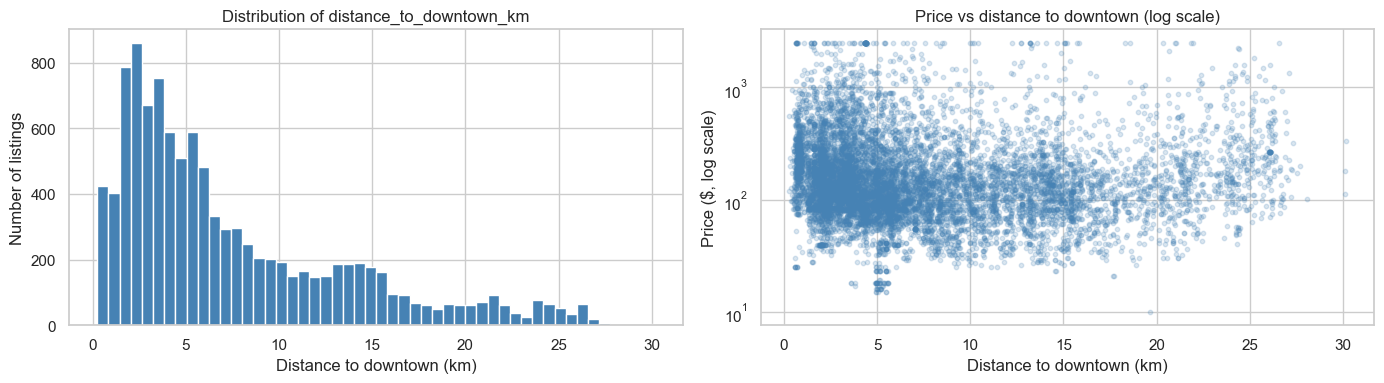

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['distance_to_downtown_km'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Distance to downtown (km)')
axes[0].set_ylabel('Number of listings')
axes[0].set_title('Distribution of distance_to_downtown_km')

axes[1].scatter(
    df['distance_to_downtown_km'],
    df['price'],
    alpha=0.2,
    s=10,
    color='steelblue',
)
axes[1].set_yscale('log')
axes[1].set_xlabel('Distance to downtown (km)')
axes[1].set_ylabel('Price ($, log scale)')
axes[1].set_title('Price vs distance to downtown (log scale)')

plt.tight_layout()
plt.show()

---
## 3. Geographic feature - cluster of listings

**Business hypothesis**  
`neighbourhood_cleansed` already captures location at the ZIP-code level, but ZIP 
boundaries are administrative, drawn for mail delivery rather than real-estate 
behavior. Two adjacent streets in the same ZIP can have very different market 
dynamics (e.g., a quiet residential block vs. a noisy entertainment corridor), 
and the same sub-market can straddle two ZIP codes. KMeans on raw coordinates 
gives a complementary, purely geometric partition that lets the model express 
neighbourhood-level micro-effects the ZIP grid cannot.

**Choice of k**  
We use k=20, which yields an average cluster size of ~525 listings (10,503 / 20). 
Fine enough to capture distinct sub-markets, coarse enough to keep each cluster 
populous enough for stable target encoding in Notebook 04. We will validate 
empirically that no cluster falls below ~50 listings.

**Latitude correction**  
KMeans uses Euclidean distance, which treats one degree of longitude as equivalent 
to one degree of latitude. At Austin's latitude (~30 degrees N), one degree of 
longitude is about 0.86 times one degree of latitude in km, so raw-coordinate 
clusters would be stretched east-west. We multiply longitude by cos(mean_latitude) 
before clustering so the resulting clusters are approximately isotropic. The raw 
longitude column in the dataframe is unchanged.

In [5]:
# Scale longitude by cos(mean_lat) so Euclidean distance ~ ground distance
mean_lat_rad = np.radians(df['latitude'].mean())
lon_scale = np.cos(mean_lat_rad)

X_geo = np.column_stack([
    df['latitude'].values,
    df['longitude'].values * lon_scale,
])

kmeans = KMeans(n_clusters=20, n_init=10, random_state=SEED)
df['geo_cluster'] = kmeans.fit_predict(X_geo)

print(f'Longitude scaling factor (cos of mean lat): {lon_scale:.4f}')
print(f'KMeans inertia: {kmeans.inertia_:.4f}')
print()
print('Cluster size distribution:')
print(df['geo_cluster'].value_counts().sort_index())

Longitude scaling factor (cos of mean lat): 0.8636
KMeans inertia: 4.0684

Cluster size distribution:
geo_cluster
0     1604
1      224
2      934
3     1008
4      269
5      254
6      142
7      152
8      173
9      278
10    1391
11     164
12     635
13     254
14     284
15     418
16     190
17     462
18     454
19    1213
Name: count, dtype: int64


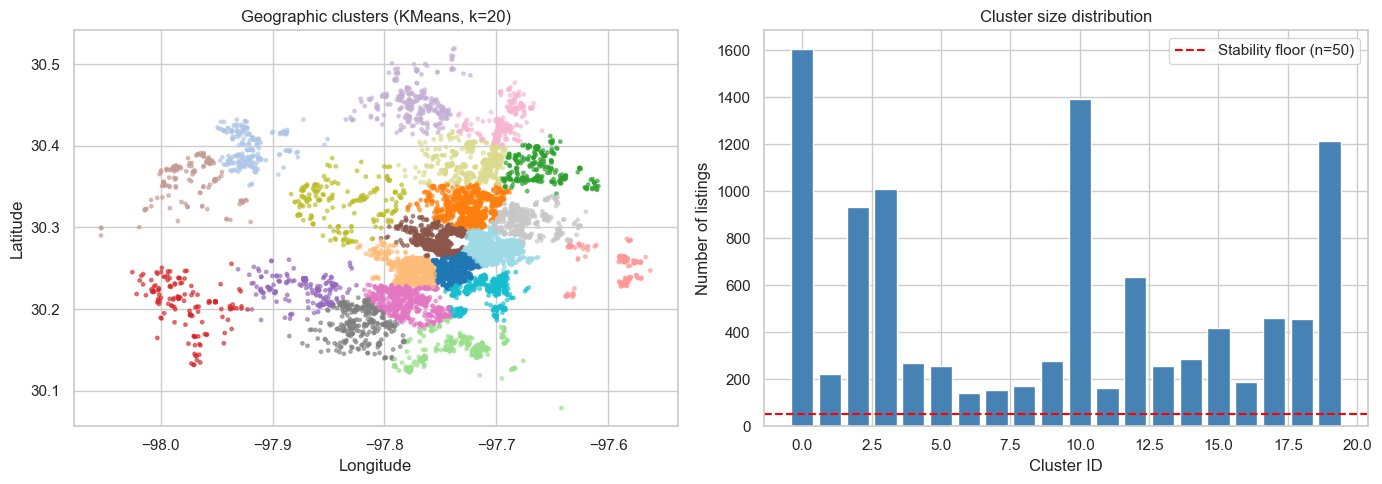

Min cluster size: 142
Max cluster size: 1604
Mean cluster size: 525.1
Clusters below 50 listings: 0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geographic scatter colored by cluster
axes[0].scatter(
    df['longitude'],
    df['latitude'],
    c=df['geo_cluster'],
    cmap='tab20',
    s=6,
    alpha=0.6,
)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Geographic clusters (KMeans, k=20)')

# Cluster size bar chart
cluster_sizes = df['geo_cluster'].value_counts().sort_index()
axes[1].bar(cluster_sizes.index, cluster_sizes.values, color='steelblue')
axes[1].axhline(50, color='red', linestyle='--', label='Stability floor (n=50)')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Number of listings')
axes[1].set_title('Cluster size distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Min cluster size: {cluster_sizes.min()}')
print(f'Max cluster size: {cluster_sizes.max()}')
print(f'Mean cluster size: {cluster_sizes.mean():.1f}')
print(f'Clusters below 50 listings: {(cluster_sizes < 50).sum()}')

---
## 4. Geographic feature - local listings density

**Business hypothesis**  
Local density captures micro-market saturation. Two competing effects are at play. 
A "competition" effect: more substitutable listings nearby exert downward pressure 
on price. A "desirability" effect: dense areas (downtown, Rainey Street, South 
Congress) are also the most in-demand. The feature is not redundant with 
`distance_to_downtown_km`: two listings 5 km from the Capitol can sit in very 
different micro-markets, one in an Airbnb-saturated corridor (East Riverside) and 
the other in a quiet residential pocket with few competitors.

**Radius choice: 500 meters**  
A 500-meter radius reflects the "walking-distance equivalence" a guest perceives 
when comparing listings. Beyond that, the listings effectively belong to a 
different micro-market.

**Method**  
We use `sklearn.neighbors.BallTree` with the `haversine` metric. Haversine on 
scikit-learn expects coordinates in radians and returns distances in radians, so 
we convert 500 m into the corresponding angular radius (500 / earth_radius_in_meters). 
We use `query_radius` for exhaustive neighbor counting rather than k-nearest neighbors. 
The count includes the listing itself, so we subtract 1 to obtain the count of 
*other* listings within 500 meters.

In [7]:
EARTH_RADIUS_M = 6_371_000.0
RADIUS_M = 500.0
radius_rad = RADIUS_M / EARTH_RADIUS_M

coords_rad = np.radians(df[['latitude', 'longitude']].values)

tree = BallTree(coords_rad, metric='haversine')

# Count neighbors within 500m for each listing
counts = tree.query_radius(coords_rad, r=radius_rad, count_only=True)

# Subtract 1: each point counts itself
df['listings_density_500m'] = counts - 1

print('listings_density_500m - summary statistics:')
print(df['listings_density_500m'].describe().round(2))
print()
print('Quantiles:')
print(df['listings_density_500m'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(1))

listings_density_500m - summary statistics:
count   10503.00
mean       66.64
std        88.52
min         0.00
25%        12.00
50%        34.00
75%        80.50
max       427.00
Name: listings_density_500m, dtype: float64

Quantiles:
0.10     5.00
0.25    12.00
0.50    34.00
0.75    80.50
0.90   157.00
0.99   393.00
Name: listings_density_500m, dtype: float64


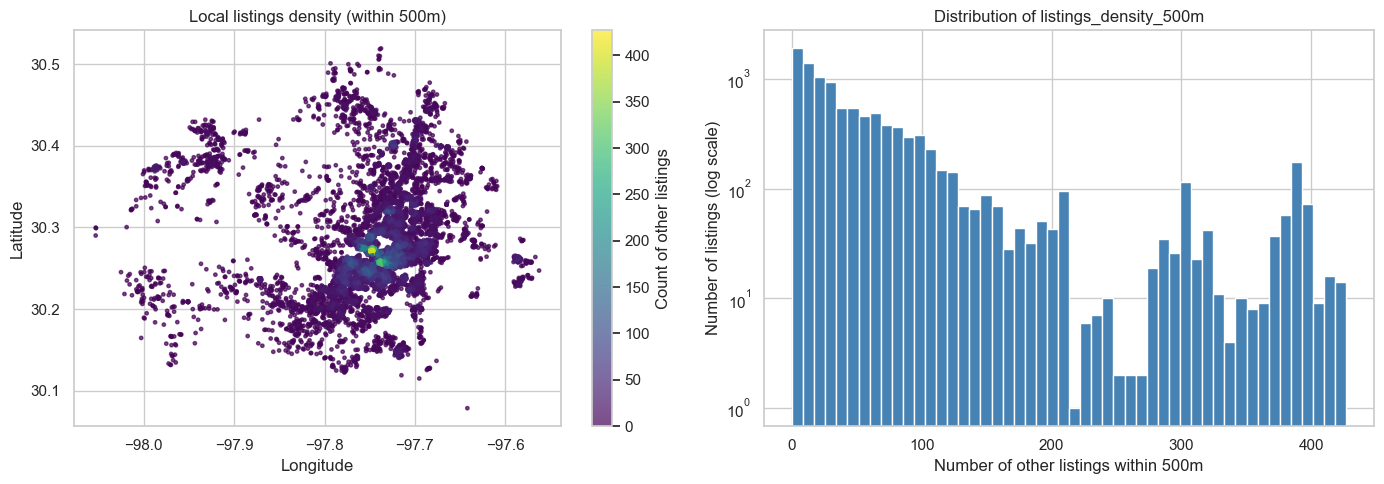

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geographic scatter colored by density
sc = axes[0].scatter(
    df['longitude'],
    df['latitude'],
    c=df['listings_density_500m'],
    cmap='viridis',
    s=6,
    alpha=0.7,
)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Local listings density (within 500m)')
plt.colorbar(sc, ax=axes[0], label='Count of other listings')

# Histogram (log y because of long tail)
axes[1].hist(df['listings_density_500m'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_xlabel('Number of other listings within 500m')
axes[1].set_ylabel('Number of listings (log scale)')
axes[1].set_title('Distribution of listings_density_500m')

plt.tight_layout()
plt.show()

In [9]:
df.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_clean,bedrooms,beds,amenities,price,availability_365,distance_to_downtown_km,geo_cluster,listings_density_500m
0,78702,30.26,-97.73,Entire guesthouse,Entire home/apt,3,1.00,1.00,2.00,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",97.00,328,1.67,0,174
1,78704,30.26,-97.76,Entire guesthouse,Entire home/apt,2,1.00,1.00,2.00,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",160.00,316,2.84,3,66
2,78741,30.23,-97.74,Entire guest suite,Entire home/apt,2,1.00,1.00,1.00,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",38.00,88,4.47,0,75
3,78702,30.26,-97.73,Entire home,Entire home/apt,3,2.00,2.00,2.00,"[""Private patio or balcony"", ""Coffee"", ""Stove""...",145.00,321,1.79,0,153
4,78741,30.24,-97.73,Entire guesthouse,Entire home/apt,2,1.00,1.00,1.00,"[""AC - split type ductless system"", ""Cleaning ...",58.00,211,4.36,0,80


---
## 5. Capacity ratio - guests per bedroom

**Business hypothesis**  
For a fixed `accommodates`, two listings with different bedroom counts are 
fundamentally different products. A 4-guest listing with 2 bedrooms (2 guests 
per bedroom) is a comfortable family apartment. A 4-guest listing with 1 bedroom 
(4 guests per bedroom) is a packed studio, hostel-grade. This occupancy density 
captures a premium-vs-budget signal that neither `accommodates` nor `bedrooms` 
expresses on its own.

**Edge case: studios**  
Airbnb's convention is that studios have `bedrooms = 0`, which would make the 
ratio diverge. We treat a studio as functionally equivalent to a 1-bedroom for 
this ratio: the sleeping space exists, it is just merged with the living area. 
The raw `bedrooms` column is left untouched; the substitution applies only to 
the ratio's denominator.

In [10]:
# How many studios are in the data
n_studios = (df['bedrooms'] == 0).sum()
print(f'Listings with bedrooms = 0 (studios): {n_studios}')
print()
print('Property types of these studios:')
print(df.loc[df['bedrooms'] == 0, 'property_type'].value_counts().head(10))

Listings with bedrooms = 0 (studios): 603

Property types of these studios:
property_type
Entire rental unit           244
Entire guesthouse            107
Entire condo                  84
Room in hotel                 28
Tiny home                     26
Entire guest suite            26
Entire home                   20
Camper/RV                     10
Entire loft                    9
Entire serviced apartment      9
Name: count, dtype: int64


In [11]:
# Studio handling: floor bedrooms at 1 for the denominator only
bedrooms_for_ratio = df['bedrooms'].clip(lower=1)
df['guests_per_bedroom'] = df['accommodates'] / bedrooms_for_ratio

print('guests_per_bedroom - summary statistics:')
print(df['guests_per_bedroom'].describe().round(2))
print()
print('Quantiles:')
print(df['guests_per_bedroom'].quantile([0.01, 0.10, 0.50, 0.90, 0.99]).round(2))
print()
print('Top 10 highest ratios (potential outliers):')
top = df.nlargest(10, 'guests_per_bedroom')[
    ['accommodates', 'bedrooms', 'guests_per_bedroom', 'property_type', 'price']
]
print(top)

guests_per_bedroom - summary statistics:
count   10503.00
mean        2.53
std         0.93
min         0.20
25%         2.00
50%         2.00
75%         3.00
max        16.00
Name: guests_per_bedroom, dtype: float64

Quantiles:
0.01   1.00
0.10   2.00
0.50   2.00
0.90   4.00
0.99   5.00
Name: guests_per_bedroom, dtype: float64

Top 10 highest ratios (potential outliers):
      accommodates  bedrooms  guests_per_bedroom       property_type   price
900             16      1.00               16.00         Entire home 2500.00
4694            15      1.00               15.00         Entire home  161.00
318             10      1.00               10.00         Entire home  199.00
9396            10      1.00               10.00  Entire rental unit  220.00
6109             9      0.00                9.00        Entire place 2500.00
1804            16      2.00                8.00        Entire condo  338.00
6956             8      0.00                8.00           Tiny home  130.00
7441    

---
## 6. Capacity ratio - bathrooms per guest

**Business hypothesis**  
This ratio captures the sanitary comfort offered by the listing, independent of 
its size. One bathroom per guest signals premium standing; one bathroom for four 
guests signals a budget or shared experience. The feature is complementary to 
`guests_per_bedroom`: that one measures sleeping density, this one measures the 
density of bathroom use. Two listings with identical `guests_per_bedroom` can 
offer very different comfort depending on this ratio.

**Edge cases**  
The numerator `bathrooms_clean` can legitimately be 0 (a shared half-bath outside 
the unit, or a private room with no dedicated bathroom). In that case the ratio 
evaluates to 0, which is semantically correct: no dedicated bathroom per guest. 
The denominator `accommodates` is always at least 1 in the cleaned dataset, so 
no division-by-zero protection is needed. We verify both points before computing.

In [12]:
n_zero_bath = (df['bathrooms_clean'] == 0).sum()
print(f'Listings with bathrooms_clean = 0: {n_zero_bath}')

if n_zero_bath > 0:
    print()
    print('Property types of these listings:')
    print(
        df.loc[df['bathrooms_clean'] == 0, 'property_type']
        .value_counts()
        .head(10)
    )
    print()
    print('Room types of these listings:')
    print(df.loc[df['bathrooms_clean'] == 0, 'room_type'].value_counts())

# Sanity check: accommodates always >= 1
assert (df['accommodates'] >= 1).all(), 'accommodates < 1 detected, would break ratio'
print()
print('Sanity check: accommodates >= 1 for all listings — OK')

Listings with bathrooms_clean = 0: 52

Property types of these listings:
property_type
Private room in rental unit    20
Room in boutique hotel          7
Entire home                     6
Private room in home            6
Entire rental unit              5
Entire condo                    2
Private room in tiny home       1
Entire guesthouse               1
Tipi                            1
Shared room in hostel           1
Name: count, dtype: int64

Room types of these listings:
room_type
Private room       35
Entire home/apt    16
Shared room         1
Name: count, dtype: int64

Sanity check: accommodates >= 1 for all listings — OK


In [13]:
df['bathrooms_per_guest'] = df['bathrooms_clean'] / df['accommodates']

print('bathrooms_per_guest - summary statistics:')
print(df['bathrooms_per_guest'].describe().round(3))
print()
print('Quantiles:')
print(df['bathrooms_per_guest'].quantile([0.01, 0.10, 0.50, 0.90, 0.99]).round(3))
print()
print('Top 10 highest ratios (most bathrooms per guest):')
top = df.nlargest(10, 'bathrooms_per_guest')[
    ['accommodates', 'bathrooms_clean', 'bathrooms_per_guest', 'property_type', 'price']
]
print(top)

bathrooms_per_guest - summary statistics:
count   10503.00
mean        0.40
std         0.25
min         0.00
25%         0.25
50%         0.33
75%         0.50
max         5.75
Name: bathrooms_per_guest, dtype: float64

Quantiles:
0.01   0.12
0.10   0.20
0.50   0.33
0.90   0.50
0.99   1.50
Name: bathrooms_per_guest, dtype: float64

Top 10 highest ratios (most bathrooms per guest):
      accommodates  bathrooms_clean  bathrooms_per_guest  \
7691             2            11.50                 5.75   
660              1             4.00                 4.00   
1397             1             3.00                 3.00   
1398             1             3.00                 3.00   
1410             1             3.00                 3.00   
1414             1             3.00                 3.00   
1415             1             3.00                 3.00   
1780             1             3.00                 3.00   
1781             1             3.00                 3.00   
3015           

**Note on Private/Shared rooms**  
The top extreme ratios all come from Private or Shared room listings where 
`bathrooms_clean` reflects the entire property's bathroom count rather than what 
is dedicated to the rented room. For an "Entire home/apt" listing the ratio is 
semantically clean; for a "Private room" it slightly over-estimates the comfort. 
We leave the ratio uncorrected: tree-based models will naturally pick up the 
`room_type` x `bathrooms_per_guest` interaction at split time, and the linear 
models' StandardScaler will compress the upper tail.

---
## 7. Amenity tier - learned weights per concept (Architecture C)

**Business hypothesis**  
Amenities are one of the strongest drivers of listing price after location and 
size. But not all amenities are equal, and Airbnb's data has many orthographic 
variants of the same concept ("Free parking on premises", "Free residential 
garage on premises", "Free street parking") that artificially inflate a naive 
count.

**Design (Architecture C)**  
We separate two concerns that have different scopes:

- **Portable concept grouping** (city-agnostic): a dictionary maps raw amenity 
  tokens to ~37 semantic concepts via include/exclude substring patterns. 
  Concepts and their patterns are stable across cities and live in 
  `src/amenity_tier.py`.
- **City-specific weighting** (learned per snapshot): a Ridge regression learns 
  the market value of each concept on `log1p(price)`. Concepts above an 80% 
  prevalence threshold are dropped to avoid lexical artifacts (mentioning 
  "Hot water" explicitly tends to be a budget-listing signal, not a high-value 
  amenity). The continuous out-of-fold score is then bucketed into 
  `{basic, premium, luxury}` via empirical terciles.

Out-of-fold (OOF) prediction is used so that each listing's score is produced 
by a model that has not seen this listing during training, neutralizing the 
target-leakage that would arise from using `price` to build a feature that will 
later be used to predict `price`. The OOF runs on the full dataset (before the 
train/test split that happens in Notebook 04); the leakage that remains is 
marginal given Ridge regularization and n=10,503.

**Inference-time use**  
The fitted Ridge model and tercile thresholds are saved as a serializable 
`bundle` that the Streamlit app loads to score new listings via 
`transform_amenity_tier`.

In [14]:
import sys
sys.path.append('..')

from src.amenity_tier import fit_amenity_tier

tier, amenity_score_oof, amenity_bundle = fit_amenity_tier(
    amenities=df['amenities'],
    price=df['price'],
)
df['amenity_tier'] = tier

# Quick summary
print(f'Tier sizes: {df["amenity_tier"].value_counts().sort_index().to_dict()}')
print(f'Discriminant concepts kept: {len(amenity_bundle["discriminant_concepts"])}')
print(f'Final Ridge alpha: {amenity_bundle["alpha"]:.3f}')
print(f'Tercile thresholds (log1p): {amenity_bundle["tercile_thresholds"].round(3)}')

Tier sizes: {'basic': 3501, 'premium': 3501, 'luxury': 3501}
Discriminant concepts kept: 25
Final Ridge alpha: 48.329
Tercile thresholds (log1p): [4.802 5.15 ]


**Validation: price monotonicity**  
The acid test of the entire amenity-tier design: the median price must increase 
strictly from `basic` to `premium` to `luxury`. If this does not hold, the 
tiering carries no signal and the design must be reviewed.

C:\Users\capri_stunt\AppData\Local\Temp\ipykernel_27140\76517409.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_tier, labels=order, showfliers=False, patch_artist=True)


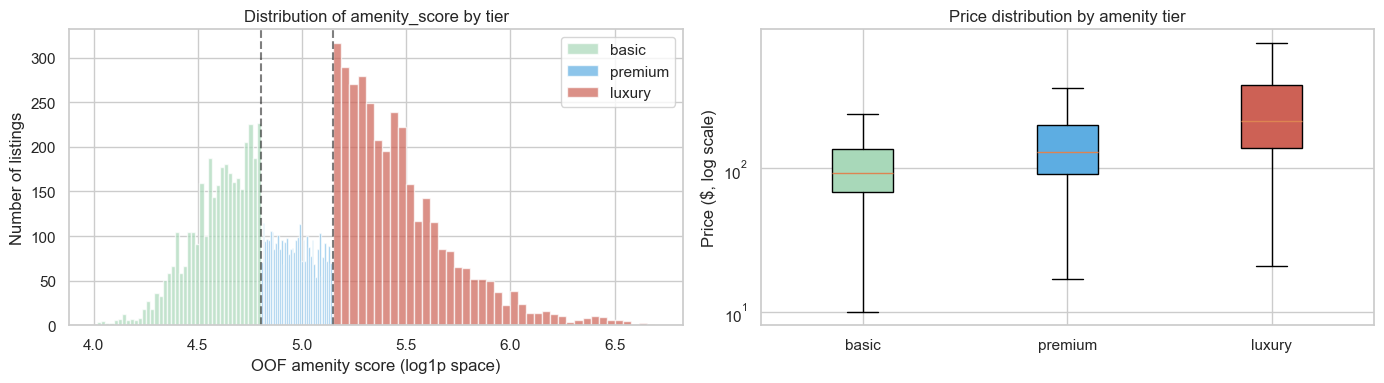

Median price by tier:
amenity_tier
basic      93.00
premium   131.00
luxury    215.00

Monotonicity check: passed


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of OOF score, colored by tier
for tier_name, color in zip(['basic', 'premium', 'luxury'], ['#a8d8b9', '#5dade2', '#cd6155']):
    mask = df['amenity_tier'] == tier_name
    axes[0].hist(
        amenity_score_oof[mask],
        bins=40,
        alpha=0.7,
        label=tier_name,
        color=color,
    )
for t in amenity_bundle['tercile_thresholds']:
    axes[0].axvline(t, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('OOF amenity score (log1p space)')
axes[0].set_ylabel('Number of listings')
axes[0].set_title('Distribution of amenity_score by tier')
axes[0].legend()

# Price boxplot by tier (log scale)
order = ['basic', 'premium', 'luxury']
data_by_tier = [df.loc[df['amenity_tier'] == t, 'price'].values for t in order]
bp = axes[1].boxplot(data_by_tier, labels=order, showfliers=False, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#a8d8b9', '#5dade2', '#cd6155']):
    patch.set_facecolor(color)
axes[1].set_yscale('log')
axes[1].set_ylabel('Price ($, log scale)')
axes[1].set_title('Price distribution by amenity tier')

plt.tight_layout()
plt.show()

# Monotonicity assertion
medians = df.groupby('amenity_tier', observed=True)['price'].median()
print('Median price by tier:')
print(medians.round(1).to_string())
print()
assert medians.is_monotonic_increasing, 'Amenity tier is NOT monotonic on price'
print('Monotonicity check: passed')

---
## 8. Final Audit & Export

We drop the intermediate columns used for engineering but no longer needed: 
`latitude` and `longitude` are now represented by `distance_to_downtown_km`, 
`geo_cluster`, and `listings_density_500m`; `amenities` and `amenities_list` 
are represented by `amenity_tier`. The final dataset contains exactly the 14 
features defined in the project specification plus the target `price`.

In addition to the feature-engineered dataset, we persist two artifacts needed 
by the Streamlit app to score new listings:

- `amenity_concepts.json`: the concept dictionary (portable, city-agnostic)
- `amenity_ridge.pkl`: the Ridge model trained on the full filtered concept 
  matrix, plus the list of discriminant concepts and the tercile thresholds

Together these let the app turn a host's amenity selection into an `amenity_tier` 
at inference time without retraining anything.

In [16]:
columns_to_drop = ['latitude', 'longitude', 'amenities']
df_final = df.drop(columns=columns_to_drop)

# Final column ordering for readability
final_column_order = [
    # Target
    'price',
    # Numeric raw
    'accommodates', 'bedrooms', 'beds', 'bathrooms_clean', 'availability_365',
    # Numeric engineered
    'distance_to_downtown_km', 'listings_density_500m',
    'guests_per_bedroom', 'bathrooms_per_guest',
    # Categorical raw
    'room_type', 'property_type', 'neighbourhood_cleansed',
    # Categorical engineered
    'geo_cluster', 'amenity_tier',
]
df_final = df_final[final_column_order]

print('=== Final shape ===')
print(f'{df_final.shape[0]:,} rows × {df_final.shape[1]} columns')
print()
print('=== Dtype and NaN audit ===')
audit = pd.DataFrame({
    'dtype': df_final.dtypes.astype(str),
    'non_null': df_final.notna().sum(),
    'nan_count': df_final.isna().sum(),
})
print(audit)

=== Final shape ===
10,503 rows × 15 columns

=== Dtype and NaN audit ===
                            dtype  non_null  nan_count
price                     float64     10503          0
accommodates                int64     10503          0
bedrooms                  float64     10503          0
beds                      float64     10503          0
bathrooms_clean           float64     10503          0
availability_365            int64     10503          0
distance_to_downtown_km   float64     10503          0
listings_density_500m       int64     10503          0
guests_per_bedroom        float64     10503          0
bathrooms_per_guest       float64     10503          0
room_type                     str     10503          0
property_type                 str     10503          0
neighbourhood_cleansed      int64     10503          0
geo_cluster                 int32     10503          0
amenity_tier             category     10503          0


In [17]:
import os
import json
import joblib

from src.amenity_tier import CONCEPTS

# Dataset export
OUTPUT_DIR = '../data/processed/Austin'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = f'{OUTPUT_DIR}/data_features.parquet'
df_final.to_parquet(OUTPUT_PATH, index=False)
print(f'Saved dataset to {OUTPUT_PATH}')
print(f'  Shape: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns')

# Amenity artifacts for the Streamlit app
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

with open(f'{MODELS_DIR}/amenity_concepts.json', 'w') as f:
    json.dump(CONCEPTS, f, indent=2)
print(f'Saved concept dictionary to {MODELS_DIR}/amenity_concepts.json')

joblib.dump(amenity_bundle, f'{MODELS_DIR}/amenity_ridge.pkl')
print(f'Saved Ridge bundle to {MODELS_DIR}/amenity_ridge.pkl')

Saved dataset to ../data/processed/Austin/data_features.parquet
  Shape: 10,503 rows x 15 columns
Saved concept dictionary to ../models/amenity_concepts.json
Saved Ridge bundle to ../models/amenity_ridge.pkl


---
## Handoff to 04_Preprocessing

The feature-engineered dataset contains 10,503 rows and 15 columns (14 features 
+ the `price` target), aligned exactly with the project specification. It is 
the starting point for `04_Preprocessing.ipynb`, which will:

- Apply the `log1p` transformation to the target
- Stratified train/test split on `neighbourhood_cleansed` (80/20)
- Build the `ColumnTransformer` pipeline: median imputation + StandardScaler 
  for numeric features, OneHotEncoder for `room_type` / `property_type` / 
  `amenity_tier`, TargetEncoder for `neighbourhood_cleansed` and `geo_cluster`
- Export `X_train`, `X_test`, `y_train`, `y_test`, and `preprocessor.pkl`

The `amenity_ridge.pkl` and `amenity_concepts.json` artifacts produced here 
will be consumed by the Streamlit app to map a user's amenity selection into 
an `amenity_tier` value at inference time.